In [2]:
import torch
import torch.nn.functional as F
from torch.nn.init import kaiming_normal
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
words = open('data/names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [10]:
# build a vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
vocab_size = len(chars) + 1

stoi = {ch: i+1 for i, ch in enumerate(chars)}  # string to index
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}  # index to string

block_size = 3  # how many characters do we take to predict the next one?

In [ ]:
# Build the dataset
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size  # initial context is all 0s (the dot)
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]  # shift the window
    return torch.tensor(X), torch.tensor(Y)

import random
random.seed(1337)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

X_train, Y_train = build_dataset(words[:n1])
X_val, Y_val = build_dataset(words[n1:n2])
X_test, Y_test = build_dataset(words[n2:])

print(X_train.shape, Y_train.shape)
print(X_val.shape, Y_val.shape)
print(X_test.shape, Y_test.shape)

<h2>BASIC</h2>

In [19]:
g = torch.Generator().manual_seed(2147483647)
embedding_dim = 10
hidden = 200
block_size = 3
input_dim = block_size * embedding_dim

C = torch.randn(vocab_size, embedding_dim, generator=g)
# Initialization: gain/sqrt(fan_in), 5/3 is gain for tanh: kaiming init.
W1 = torch.randn(input_dim, hidden, generator=g)    * (5/3) / (input_dim**0.5)
b1 = torch.zeros(hidden)
W2 = torch.randn(hidden, vocab_size, generator=g)   * (5/3) / (hidden**0.5)
b2 = torch.zeros(vocab_size)

bngain = torch.ones((1, hidden))
bnbias = torch.zeros((1, hidden))
bnmean_running = torch.zeros((1, hidden))
bnstd_running = torch.ones((1, hidden))

parameters = [C, W1, b1, W2, b2, bnbias, bngain]
for p in parameters:
    p.requires_grad = True

In [20]:
lri = []
lossi = []
stepi = []

Step 0: loss 3.7851
Step 10000: loss 2.0157
Step 20000: loss 2.2046
Step 30000: loss 1.9213
Step 40000: loss 2.1524
Step 50000: loss 2.2077
Step 60000: loss 2.3009
Step 70000: loss 2.4307
Step 80000: loss 2.1724
Step 90000: loss 2.1408


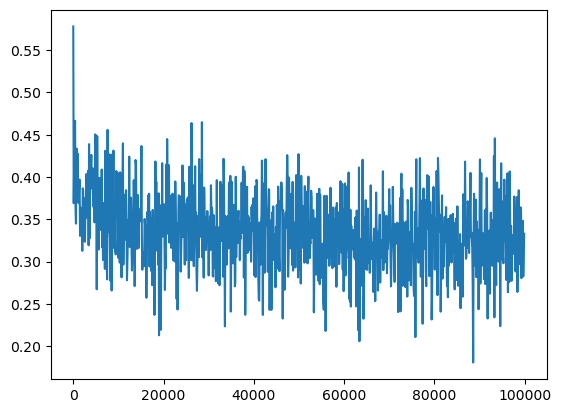

In [ ]:
batch_size = 32
n_epochs = 100000

for i in range(n_epochs):
    # Minibatch of data
    ix = torch.randint(0, X_train.shape[0], (batch_size,))
    X, Y = X_train[ix], Y_train[ix]  # batch of input and output data

    # Forward pass
    emb = C[X]
    h_preact = emb.view(-1, input_dim) @ W1 # + b1 : b1 isn't really needed as batch norm will add a bias

    # Batch norm stuff.
    bnmeani = h_preact.mean(0, keepdim=True)  # batch mean
    bnstdi = h_preact.std(0, keepdim=True)  # batch std
    h_preact = bngain*((h_preact - bnmeani) / bnstdi) + bnbias  # layer norm
    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
    
    # Non linearity
    h = torch.tanh(h_preact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    
    # backward pass
    for p in parameters:
        p.grad = None  # zero the gradients
    loss.backward()

    # Update.    
    lr = 0.1 if i < n_epochs//2 else 0.01  # learning rate
    for p in parameters:
        p.data -= lr * p.grad  # gradient descent step

    # Track loss
    if i % 10000 == 0:
        print(f"Step {i}: loss {loss.item():.4f}")
    if i % 100 == 0:
        stepi.append(i)
        lossi.append(loss.log10().item())

plt.plot(stepi, lossi)
plt.hist(h_preact.view(-1).tolist(), bins=50)
h_preact.shape, h_preact.mean(), h_preact.std(), h_preact.max(), h_preact.min()

In [ ]:
# Caclulate the loss on the validation set
def get_loss(X, Y):
    emb = C[X]
    h_preact = emb.view(-1, input_dim) @ W1 + b1
    h_preact = bngain*((h_preact - bnmean_running) / bnstd_running) + bnbias  # layer norm
    h = torch.tanh(h_preact)
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, Y)
    return loss.item()

print("Total Loss on train: ", get_loss(X_train, Y_train))
print("Total Loss on validation: ", get_loss(X_val, Y_val))
print("Total Loss on test: ", get_loss(X_test, Y_test))


Total Loss on train:  2.0975863933563232
Total Loss on validation:  2.134439706802368
Total Loss on test:  2.128506898880005


In [25]:
g = torch.Generator().manual_seed(2147483647)

for _ in range(20):
    out = []
    context = [0] * block_size  # initial context is all 0s (the dot)
    while True:
        emb = C[torch.tensor(context)]
        h_preact = emb.view(-1, input_dim) @ W1 + b1
        h_preact = bngain*((h_preact - bnmean_running) / bnstd_running) + bnbias  # layer norm
        h = torch.tanh(h_preact)
        logits = h @ W2 + b2
        probs = F.softmax(logits)
        ix = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join([itos[i] for i in out]))

junide.
jakarie.
parfay.
adria.
jirrito.
cous.
tez.
kalinaa.
zamilena.
jededailrwiett.
sejainayla.
terinveum.
kyfontumj.
ponnelina.
jaylinora.
yarion.
kaelandreed.
miki.
wynin.
anaasnessi.


C:\Users\Nitin\AppData\Local\Temp\ipykernel_27040\65717581.py:12: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = F.softmax(logits)


<h2>TORCHIFY</h2>

In [ ]:
# Let's train a deeper network
# The classes we create here are the same API as nn.Module in PyTorch

class Linear:
  
  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
    self.bias = torch.zeros(fan_out) if bias else None
  
  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out
  
  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias])


class BatchNorm1d:
  def __init__(self, dim, eps=1e-5, momentum=0.1):
    self.eps = eps
    self.momentum = momentum
    self.training = True
    # parameters (trained with backprop)
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)
    # buffers (trained with a running 'momentum update')
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)
  
  def __call__(self, x):
    # calculate the forward pass
    if self.training:
      xmean = x.mean(0, keepdim=True) # batch mean
      xvar = x.var(0, keepdim=True) # batch variance
    else:
      xmean = self.running_mean
      xvar = self.running_var
    xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
    self.out = self.gamma * xhat + self.beta
    # update the buffers
    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
        self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
    return self.out
  
  def parameters(self):
    return [self.gamma, self.beta]

class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out
  def parameters(self):
    return []

n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 100 # the number of neurons in the hidden layer of the MLP
g = torch.Generator().manual_seed(2147483647) # for reproducibility

C = torch.randn((vocab_size, n_embd),            generator=g)
layers = [
  Linear(n_embd * block_size, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(           n_hidden, vocab_size, bias=False), BatchNorm1d(vocab_size),
]
# layers = [
#   Linear(n_embd * block_size, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, n_hidden), Tanh(),
#   Linear(           n_hidden, vocab_size),
# ]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].gamma *= 0.1
  #layers[-1].weight *= 0.1
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 1.0 #5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

47024


In [14]:
# same optimization as last time
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
  
  # minibatch construct
  ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
  Xb, Yb = X_train[ix], Y_train[ix] # batch X,Y
  
  # forward pass
  emb = C[Xb] # embed the characters into vectors
  x = emb.view(emb.shape[0], -1) # concatenate the vectors
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, Yb) # loss function
  
  # backward pass
  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph
  for p in parameters:
    p.grad = None
  loss.backward()
  
  # update
  lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  if i % 10000 == 0: # print every once in a while
    print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
  lossi.append(loss.log10().item())
  with torch.no_grad():
    ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

  if i >= 1000:
    break # AFTER_DEBUG: would take out obviously to run full optimization

      0/ 200000: 3.2992


layer 2 (      Tanh): mean -0.00, std 0.64, saturated: 2.66%
layer 5 (      Tanh): mean -0.00, std 0.65, saturated: 1.84%
layer 8 (      Tanh): mean +0.01, std 0.65, saturated: 2.28%
layer 11 (      Tanh): mean +0.00, std 0.65, saturated: 1.88%
layer 14 (      Tanh): mean -0.00, std 0.66, saturated: 1.38%


Text(0.5, 1.0, 'activation distribution')

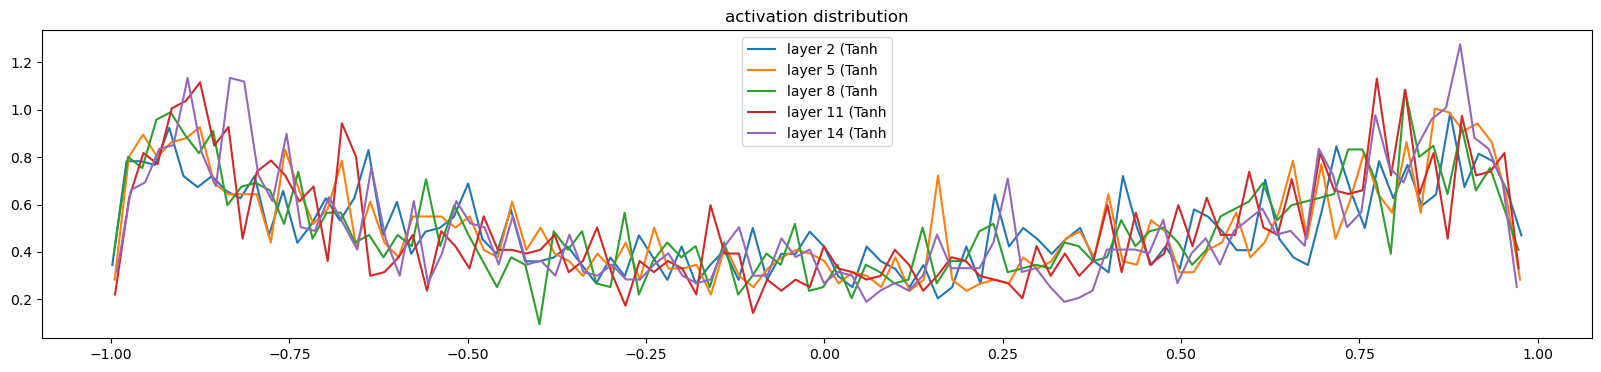

In [15]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')

layer 2 (      Tanh): mean -0.000000, std 2.480636e-03
layer 5 (      Tanh): mean +0.000000, std 2.298487e-03
layer 8 (      Tanh): mean +0.000000, std 2.143598e-03
layer 11 (      Tanh): mean -0.000000, std 2.031660e-03
layer 14 (      Tanh): mean +0.000000, std 2.288070e-03


Text(0.5, 1.0, 'gradient distribution')

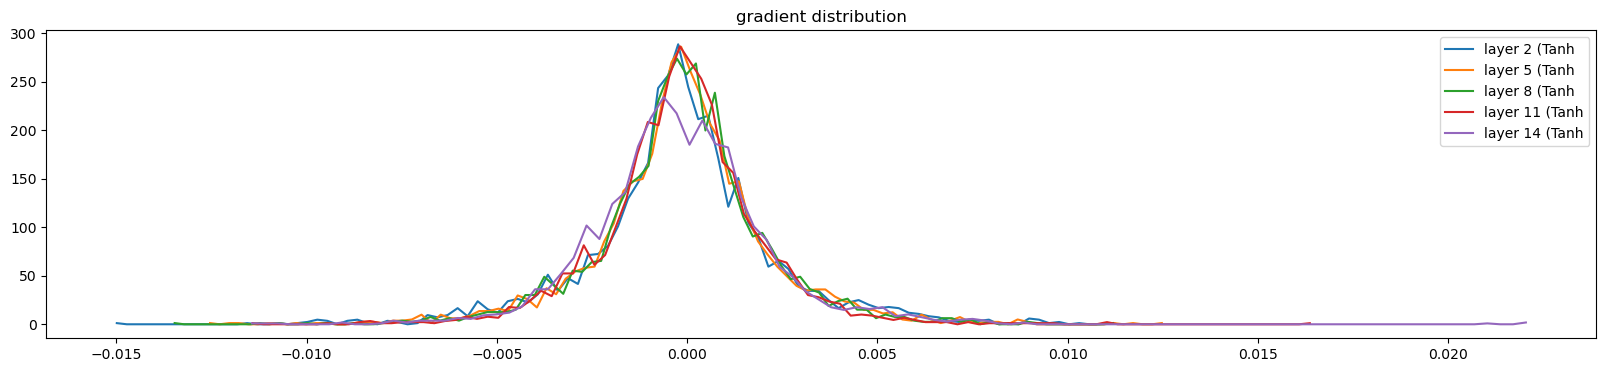

In [16]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 6.673342e-03 | grad:data ratio 6.666786e-03
weight  (30, 100) | mean -0.000065 | std 9.260689e-03 | grad:data ratio 4.892316e-02
weight (100, 100) | mean -0.000042 | std 7.466270e-03 | grad:data ratio 7.296570e-02
weight (100, 100) | mean -0.000058 | std 6.905635e-03 | grad:data ratio 6.728654e-02
weight (100, 100) | mean -0.000026 | std 6.242755e-03 | grad:data ratio 6.128203e-02
weight (100, 100) | mean +0.000081 | std 6.306329e-03 | grad:data ratio 6.198395e-02
weight  (100, 27) | mean -0.000001 | std 1.372733e-02 | grad:data ratio 1.319558e-01


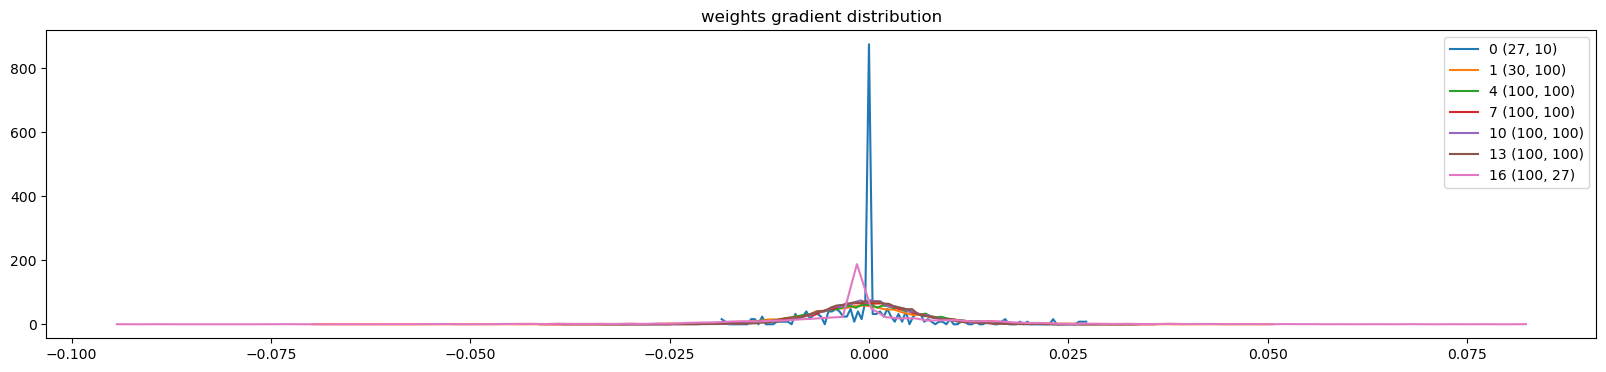

In [17]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

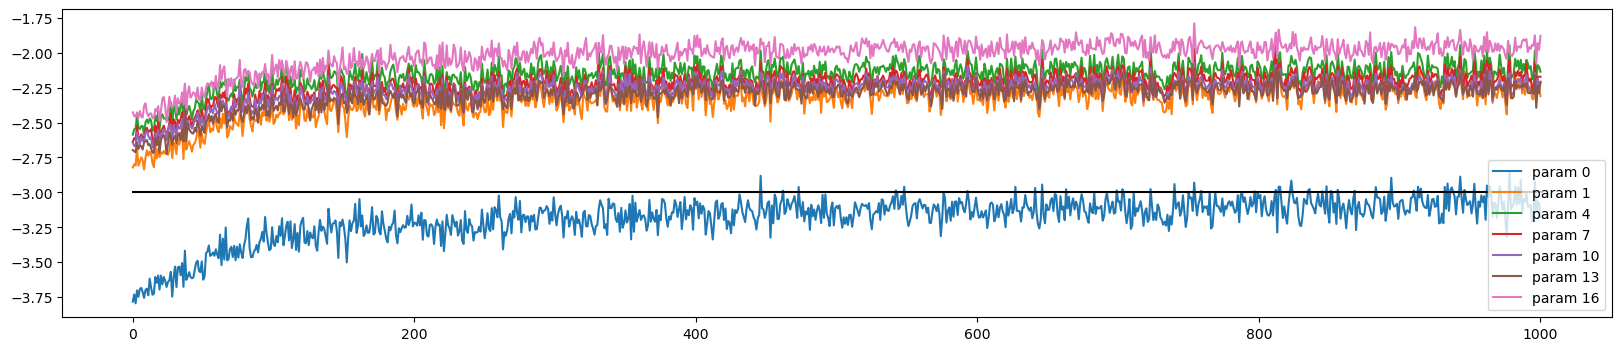

In [18]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [19]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (X_train, Y_train),
    'val': (X_val, Y_val),
    'test': (X_test, Y_test),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  x = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  for layer in layers:
    x = layer(x)
  loss = F.cross_entropy(x, y)
  print(split, loss.item())

# put layers into eval mode
for layer in layers:
  layer.training = False
split_loss('train')
split_loss('val')

train 2.396732807159424
val 2.3996694087982178


In [20]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass the neural net
      emb = C[torch.tensor([context])] # (1,block_size,n_embd)
      x = emb.view(emb.shape[0], -1) # concatenate the vectors
      for layer in layers:
        x = layer(x)
      logits = x
      probs = F.softmax(logits, dim=1)
      # sample from the distribution
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      # shift the context window and track the samples
      context = context[1:] + [ix]
      out.append(ix)
      # if we sample the special '.' token, break
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out)) # decode and print the generated word

mria.
mmyan.
seelen.
hayla.
rethaslendrle.
radered.
elii.
shi.
jea.
ekeisean.
xarlely.
kohlkaain.
shibergshiriel.
kinne.
jel.
qxnte.
cayu.
men.
dar.
yarue.
